# Problem Statement
### HR Analytics
A training institute which conducts training for analytics/ data science wants to expand their business to manpower recruitment (data science only) as well.

Company gets large number of signups for their trainings. Now, company wants to connect these enrollees with their clients who are looking to hire employees working in the same domain. Before that, it is important to know which of these candidates are really looking for a new employment. They have student information related to demographics, education, experience and features related to training as well.

To understand the factors that lead a person to look for a job change, the agency wants you to design a model that uses the current credentials/demographics/experience to predict the probability of an enrollee to look for a new job.


### Objective

* To predict whether the enrollee will be interested/looking for job change


# Data set

### Variable - Description
<br>enrollee_id - Unique ID for enrollee
<br>city - City code
<br>city_development_index - Developement index of the city (scaled)
<br>gender - Gender
<br>relevent_experience - Relevent experience
<br>enrolled_university - Type of University course enrolled if any
<br>education_level - Education level
<br>major_discipline - Major discipline
<br>experience - Total experience in years
<br>company_size -No of employees in current employer's company
<br>company_type - Type of current employer
<br>last_new_job -Difference in years between previous job and current job
<br>training_hours - training hours completed

### target

<br>0 - Not looking for job change
<br>1 - Looking for a job change

In [1]:
# import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


In [2]:
# read the data
train = pd.read_csv('train_jqd04QH.csv')
test = pd.read_csv('test_KaymcHn.csv')


In [3]:
# total no rows and cols
train.shape, test.shape

((18359, 14), (15021, 13))

In [4]:
# get datatype
train.dtypes

,0
enrollee_id,int64
city,object
city_development_index,float64
gender,object
relevent_experience,object
enrolled_university,object
education_level,object
major_discipline,object
experience,object
company_size,object


In [5]:
# get all details
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18359 entries, 0 to 18358
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             18359 non-null  int64  
 1   city                    18359 non-null  object 
 2   city_development_index  18359 non-null  float64
 3   gender                  14261 non-null  object 
 4   relevent_experience     18359 non-null  object 
 5   enrolled_university     18017 non-null  object 
 6   education_level         17902 non-null  object 
 7   major_discipline        15521 non-null  object 
 8   experience              18300 non-null  object 
 9   company_size            13580 non-null  object 
 10  company_type            13320 non-null  object 
 11  last_new_job            17992 non-null  object 
 12  training_hours          18359 non-null  int64  
 13  target                  18359 non-null  int64  
dtypes: float64(1), int64(3), object(10)
me

In [6]:
# to see first 3 rows
train.head(3)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,23798,city_149,0.689,Male,Has relevent experience,no_enrollment,Graduate,STEM,3,100-500,Pvt Ltd,1,106,0
1,29166,city_83,0.923,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,<10,Funded Startup,1,69,0
2,46,city_16,0.910,NaN,Has relevent experience,no_enrollment,Graduate,STEM,6,50-99,Public Sector,2,4,0


In [7]:
# look for missing data
train.isna().sum()

,0
enrollee_id,0
city,0
city_development_index,0
gender,4098
relevent_experience,0
enrolled_university,342
education_level,457
major_discipline,2838
experience,59
company_size,4779


In [8]:
# only cols with missing data
train.columns[train.isna().any()]

Index(['gender', 'enrolled_university', 'education_level', 'major_discipline',
       'experience', 'company_size', 'company_type', 'last_new_job'],
      dtype='object')

In [9]:
na_cols = train.columns[train.isna().any()]

In [10]:
train.isna().sum()[train.isna().sum() > 0].index.tolist()

['gender',
 'enrolled_university',
 'education_level',
 'major_discipline',
 'experience',
 'company_size',
 'company_type',
 'last_new_job']

In [11]:
train.isna().sum()[train.isna().sum() > 0]

,0
gender,4098
enrolled_university,342
education_level,457
major_discipline,2838
experience,59
company_size,4779
company_type,5039
last_new_job,367


In [12]:
# missing data in % for each col
train[na_cols].isna().sum()/train.shape[0]*100

,0
gender,22.321477
enrolled_university,1.862847
education_level,2.489242
major_discipline,15.458358
experience,0.321368
company_size,26.030830
company_type,27.447029
last_new_job,1.999020


In [13]:
(train[na_cols].isna().sum()/train.shape[0]*100).sort_values()

,0
experience,0.321368
enrolled_university,1.862847
last_new_job,1.999020
education_level,2.489242
major_discipline,15.458358
gender,22.321477
company_size,26.030830
company_type,27.447029


In [14]:
# chk duplicates
train.duplicated().sum()

np.int64(0)

In [15]:
# check target data
train['target'].value_counts()

,count
target,
0,15934
1,2425


In [16]:
train.target.value_counts()

,count
target,
0,15934
1,2425


In [17]:
train.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'target'],
      dtype='object')

In [19]:
#train.city_development_index.value_counts()
#city development index

#train['city development index'].value_counts()


In [20]:
df1 = train.copy()

In [21]:
df1.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'target'],
      dtype='object')

In [22]:
#df1['city development index'] = df1['city development index']

In [23]:
df1.rename(columns={'city_development_index': 'city development index'},inplace=True)
df1.columns

Index(['enrollee_id', 'city', 'city development index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'target'],
      dtype='object')

In [77]:
#df1.city development index.value_counts()

In [78]:
df1['city development index'].value_counts()

,count
city development index,
0.920,5185
0.624,1672
0.910,1654
0.926,1472
0.698,655
...,...
0.556,4
0.807,4
0.625,3


<Axes: xlabel='target'>

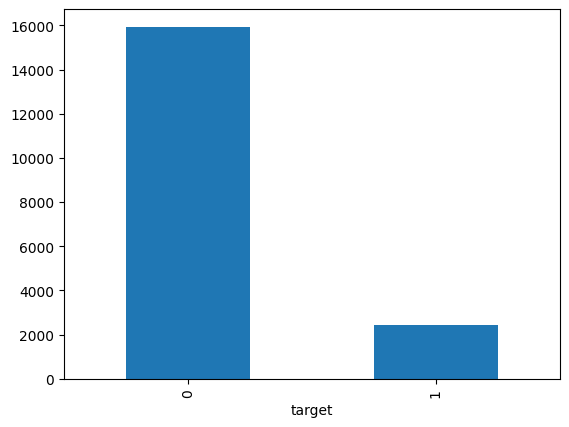

In [79]:
train.target.value_counts().plot(kind='bar')

In [80]:
tgt_coll = ['target']
ign_cols = ['enrollee_id']

In [81]:
# check unique values

train.nunique()

,0
enrollee_id,18359
city,123
city_development_index,93
gender,3
relevent_experience,2
enrolled_university,3
education_level,5
major_discipline,6
experience,22
company_size,8


In [82]:
# listing unique values of all cols
for col in train.drop(columns=ign_cols).columns:
    print(col)
    print(train[col].unique())


city
['city_149' 'city_83' 'city_16' 'city_64' 'city_100' 'city_21' 'city_114'
 'city_103' 'city_97' 'city_160' 'city_65' 'city_90' 'city_75' 'city_136'
 'city_159' 'city_67' 'city_28' 'city_10' 'city_73' 'city_76' 'city_104'
 'city_27' 'city_30' 'city_61' 'city_99' 'city_41' 'city_142' 'city_9'
 'city_116' 'city_128' 'city_74' 'city_69' 'city_1' 'city_176' 'city_40'
 'city_123' 'city_152' 'city_165' 'city_89' 'city_36' 'city_44' 'city_46'
 'city_45' 'city_134' 'city_93' 'city_180' 'city_162' 'city_84' 'city_138'
 'city_173' 'city_19' 'city_71' 'city_158' 'city_23' 'city_102' 'city_105'
 'city_91' 'city_11' 'city_13' 'city_57' 'city_20' 'city_14' 'city_37'
 'city_115' 'city_50' 'city_167' 'city_12' 'city_143' 'city_126' 'city_77'
 'city_101' 'city_150' 'city_179' 'city_107' 'city_175' 'city_146'
 'city_98' 'city_166' 'city_118' 'city_129' 'city_127' 'city_24' 'city_81'
 'city_26' 'city_139' 'city_94' 'city_70' 'city_145' 'city_157' 'city_111'
 'city_78' 'city_80' 'city_33' 'city_7' 'ci

<Axes: xlabel='training_hours', ylabel='Density'>

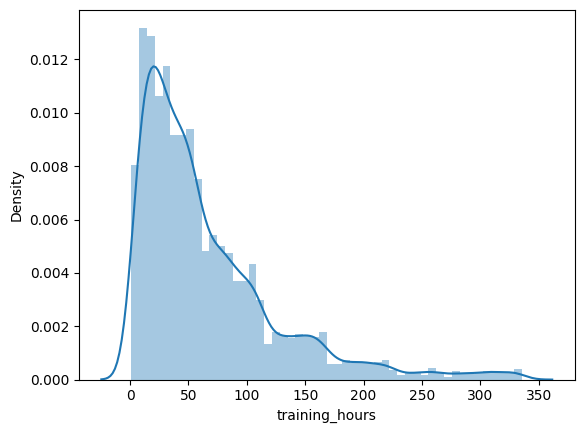

In [83]:
sns.distplot(train['training_hours'])

* most ppl fall under low to moderate training hours
* long training hours attended/done by only few
* peak is 15-50 hrs


In [84]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18359 entries, 0 to 18358
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             18359 non-null  int64  
 1   city                    18359 non-null  object 
 2   city_development_index  18359 non-null  float64
 3   gender                  14261 non-null  object 
 4   relevent_experience     18359 non-null  object 
 5   enrolled_university     18017 non-null  object 
 6   education_level         17902 non-null  object 
 7   major_discipline        15521 non-null  object 
 8   experience              18300 non-null  object 
 9   company_size            13580 non-null  object 
 10  company_type            13320 non-null  object 
 11  last_new_job            17992 non-null  object 
 12  training_hours          18359 non-null  int64  
 13  target                  18359 non-null  int64  
dtypes: float64(1), int64(3), object(10)
me

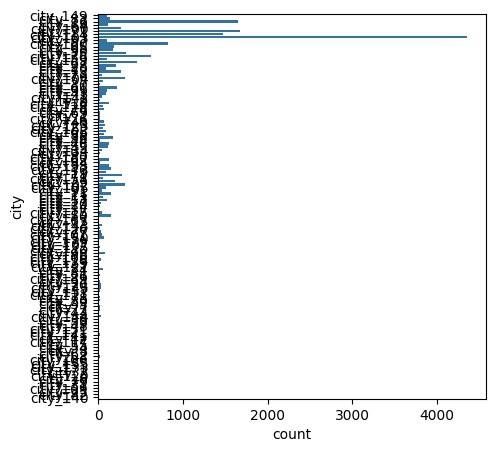

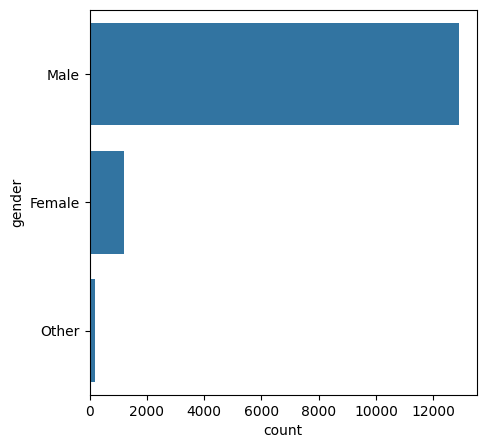

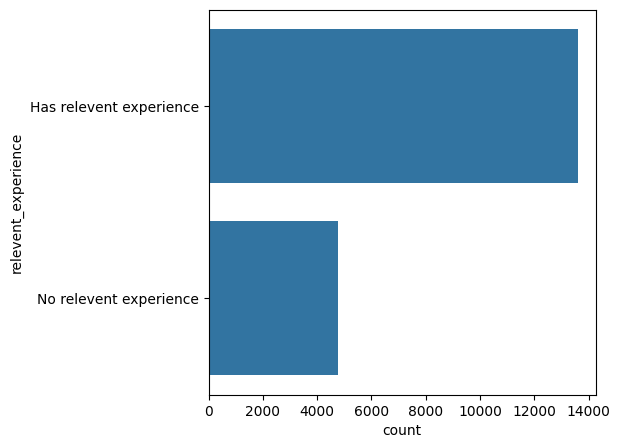

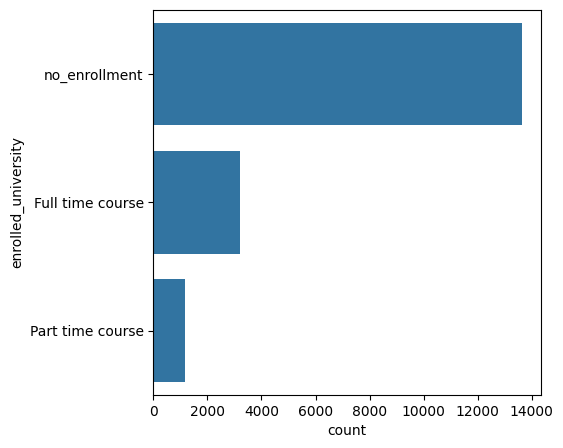

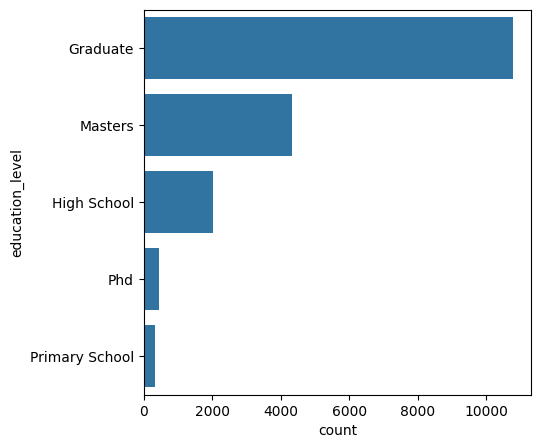

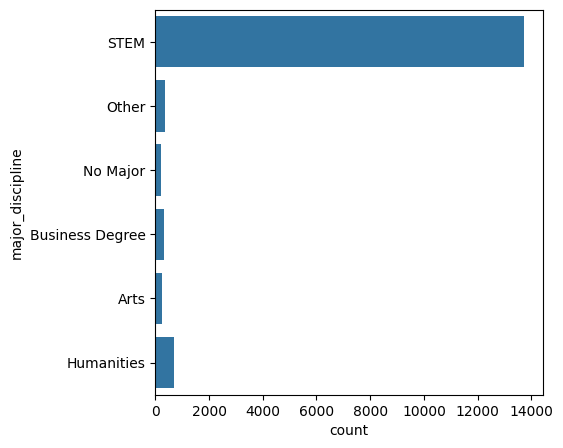

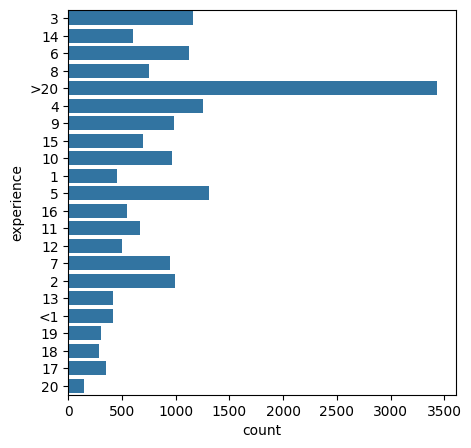

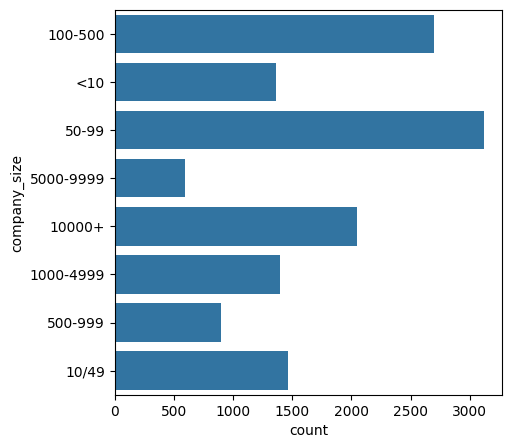

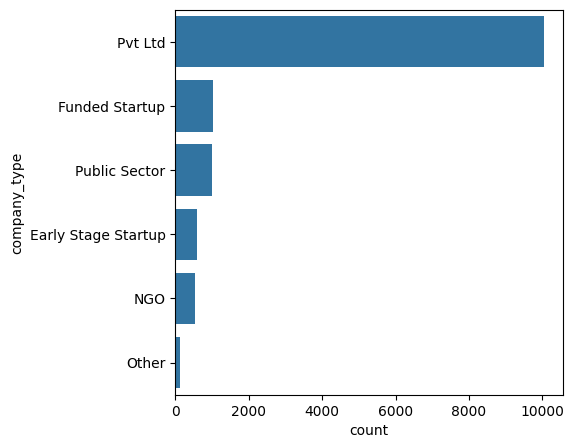

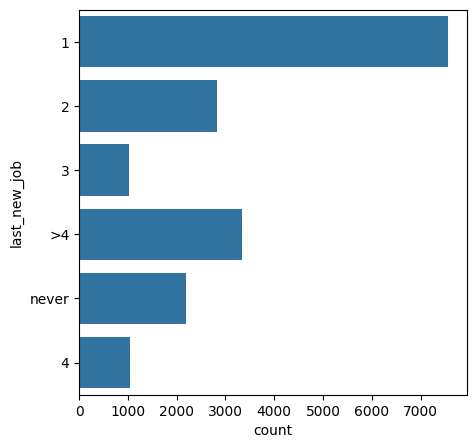

In [85]:
for col in train.select_dtypes(include='object').columns:
  plt.figure(figsize=(5,5))
  sns.countplot(train[col])
  plt.show()


<Axes: ylabel='city'>

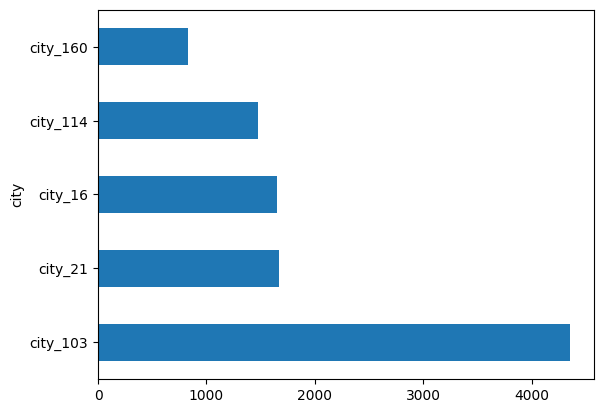

In [86]:

train['city'].value_counts().nlargest(5).plot(kind='barh')

In [87]:
cat_cols = train.select_dtypes(include='object').columns
cat_cols


Index(['city', 'gender', 'relevent_experience', 'enrolled_university',
       'education_level', 'major_discipline', 'experience', 'company_size',
       'company_type', 'last_new_job'],
      dtype='object')

In [88]:
num_cols = train.drop(columns=ign_cols+tgt_coll).select_dtypes(exclude='object').columns
num_cols

Index(['city_development_index', 'training_hours'], dtype='object')

In [89]:
tgt_coll

['target']

In [90]:
ign_cols

['enrollee_id']

In [91]:
numm_colll = ['city_development_index', 'training_hours']
numm_colll

cat_coll = ['city', 'gender', 'relevent_experience', 'enrolled_university',
       'education_level', 'major_discipline', 'experience', 'company_size',
       'company_type', 'last_new_job']
cat_coll

['city',
 'gender',
 'relevent_experience',
 'enrolled_university',
 'education_level',
 'major_discipline',
 'experience',
 'company_size',
 'company_type',
 'last_new_job']

In [92]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [93]:
# cat pipe

cat_pipe_enc = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # missing values with mode
    ('ohe', OneHotEncoder(handle_unknown='ignore')) #category encoding
])

cat_pipe_enc

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('ohe', OneHotEncoder(handle_unknown='ignore'))])

train data
color      red   green blue
-----
red         1     0     0
green       0     1     0
blue        0     0     1

test data
red         1     0     0
orange      0     0     0
pink        0     0     0   


  

In [94]:
#num pipe
num_pipe_enc = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # missing values
    ('scaler', StandardScaler()) # standardization
])
num_pipe_enc


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [95]:
# map transformation to features

preprocess = ColumnTransformer(transformers=[
    ('cat_enc', cat_pipe_enc, cat_cols),
    ('num_enc', num_pipe_enc, num_cols)
    ])


In [96]:
from sklearn.linear_model import LogisticRegression

In [97]:
#integrate preprocessing and model
model_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression())
])

In [98]:
model_pipeline

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat_enc',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['city', 'gender', 'relevent_experience', 'enrolled_university',
       'education_level', 'major_discipline', 'experience', 'company_size',
       'company_type', 'last_new_job'],
      dtype='object')),
                                                 ('num_enc',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['city_development_index', 'training_hours'], dtype='object'))])),
                ('model', LogisticRegression())])

In [99]:
X = train.drop(columns=ign_cols+tgt_coll)
y = train['target']

In [100]:
X.head(2)

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
0,city_149,0.689,Male,Has relevent experience,no_enrollment,Graduate,STEM,3,100-500,Pvt Ltd,1,106
1,city_83,0.923,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,<10,Funded Startup,1,69


In [101]:
y.head(2)

,target
0,0
1,0


In [102]:
from sklearn.model_selection import train_test_split

In [103]:
train_X, val_X, train_y, val_y = train_test_split(X, y, test_size=0.1, random_state=42)
train_X.shape, val_X.shape, train_y.shape, val_y.shape

((16523, 12), (1836, 12), (16523,), (1836,))

In [104]:
'''
print(test_X.shape, test_y.shape)
del test_X, test_y
print(test_X.shape, test_y.shape)
'''

'\nprint(test_X.shape, test_y.shape)\ndel test_X, test_y\nprint(test_X.shape, test_y.shape)\n'

In [105]:
train_y.value_counts(), val_y.value_counts()

(target
 0    14349
 1     2174
 Name: count, dtype: int64,
 target
 0    1585
 1     251
 Name: count, dtype: int64)

In [106]:
#fit the model
model_pipeline.fit(train_X, train_y)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat_enc',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['city', 'gender', 'relevent_experience', 'enrolled_university',
       'education_level', 'major_discipline', 'experience', 'company_size',
       'company_type', 'last_new_job'],
      dtype='object')),
                                                 ('num_enc',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['city_development_index', 'training_hours'], dtype='object'))])),
                ('model', LogisticRegression())])

In [107]:
model_pipeline.predict(val_X)

array([0, 0, 0, ..., 0, 0, 0])

In [108]:
model_pipeline.predict_proba(val_X)

array([[0.83788855, 0.16211145],
       [0.89245315, 0.10754685],
       [0.9161205 , 0.0838795 ],
       ...,
       [0.88705445, 0.11294555],
       [0.92663684, 0.07336316],
       [0.91339528, 0.08660472]])

In [109]:
'''
            predict_proba              PREDICT
          0-nochg      1-look
array([[0.83788855, 0.16211145],       0-nochg
       [0.89245315, 0.10754685],       0-nochg
       [0.9161205 , 0.0838795 ],       0-nochg
       [0.2500000,  0.7500000],        1-look/chg

'''

'\n            predict_proba              PREDICT\n          0-nochg      1-look\narray([[0.83788855, 0.16211145],       0-nochg\n       [0.89245315, 0.10754685],       0-nochg  \n       [0.9161205 , 0.0838795 ],       0-nochg\n       [0.2500000,  0.7500000],        1-look/chg\n\n'

In [110]:
from sklearn.metrics import roc_auc_score

In [111]:
def model_train_cal_eval(train_X, train_y, val_X, val_y, model_pipeline):
  predicted_train_tgt = model_pipeline.predict_proba(train_X)[:,1]
  predicted_val_tgt = model_pipeline.predict_proba(val_X)[:,1]

  print('Train Score:',roc_auc_score(train_y, predicted_train_tgt))
  print('Val Score:',roc_auc_score(val_y, predicted_val_tgt))




In [112]:
model_train_cal_eval(train_X, train_y, val_X, val_y, model_pipeline)

Train Score: 0.6754433585985016
Val Score: 0.6222805937134743


In [113]:
sub = pd.read_csv('sample_submission_sxfcbdx.csv')
sub.head()

,enrollee_id,target
0,16548,0
1,12036,0
2,11061,0
3,5032,0
4,17599,0


In [114]:
sub['target'] = model_pipeline.predict_proba(test.drop(columns=ign_cols))[:,1]
sub.to_csv('sub1_logreg_imb.csv',index=False)

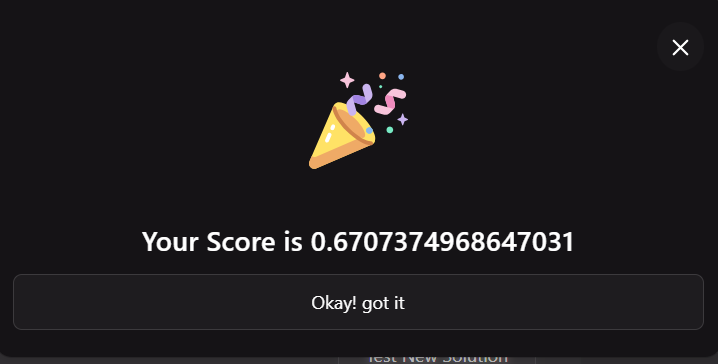

In [115]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [116]:
param_1 = [
    {
        'model' : [LogisticRegression()],
        'model__penalty' : ['l2',None, 'l1','elasticnet'],
        'model__C' : [0.5, 3]
    },
    {
        'model' : [DecisionTreeClassifier()],
        'model__max_depth' : [3, 5]
    }
]

p1-g1-lr 2*2 = 4 be = 0.665

p2-g2-dt 1*2 = 2 be = 0.665

In [117]:
grid_1 = GridSearchCV(estimator=model_pipeline, param_grid=param_1, cv=2,scoring='roc_auc')

In [118]:
from imblearn.over_sampling import RandomOverSampler


In [119]:
over_sampling = RandomOverSampler()

In [120]:
train_X.shape, train_y.shape

((16523, 12), (16523,))

In [121]:
train_y.value_counts()

,count
target,
0,14349
1,2174


In [122]:
train_X_os, train_y_os = over_sampling.fit_resample(train_X, train_y)

In [123]:
train_y_os.value_counts()

,count
target,
0,14349
1,14349


In [70]:
grid_1.fit(train_X_os, train_y_os)

GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('cat_enc',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['city', 'gender', 'relevent_experience', 'enrolled_university',
       'education_level', 'major_discipline', 'experience', 'company_size',...
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['city_development_index', 'training_hours'], dtype='object'))])),
                                       ('model', LogisticRegression())]),
             param_grid=[{'model': [LogisticRegression()], 'model__C': [0.5, 3],
                          'model__penalty': ['l2', None, 'l1', 'elasticnet']},
                         {'model': [DecisionTreeClassifier()],
                          'model__max_depth': [3, 5]}],
             scoring='roc_auc')

In [71]:
grid_1.best_params_

{'model': LogisticRegression(), 'model__C': 0.5, 'model__penalty': 'l2'}

In [72]:
grid_1.best_estimator_

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat_enc',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['city', 'gender', 'relevent_experience', 'enrolled_university',
       'education_level', 'major_discipline', 'experience', 'company_size',
       'company_type', 'last_new_job'],
      dtype='object')),
                                                 ('num_enc',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['city_development_index', 'training_hours'], dtype='object'))])),
                ('model', LogisticRegression(C=0.5))])

In [73]:
res_df_1 = pd.DataFrame(grid_1.cv_results_)
#grid_1.cv_results_
pd.set_option('display.max_colwidth', 1000)
res_df_1[['param_model','params','mean_test_score','rank_test_score']]

,param_model,params,mean_test_score,rank_test_score
0,LogisticRegression(),"{'model': LogisticRegression(), 'model__C': 0.5, 'model__penalty': 'l2'}",0.665914,1
1,LogisticRegression(),"{'model': LogisticRegression(), 'model__C': 0.5, 'model__penalty': None}",0.665319,3
2,LogisticRegression(),"{'model': LogisticRegression(), 'model__C': 0.5, 'model__penalty': 'l1'}",NaN,7
3,LogisticRegression(),"{'model': LogisticRegression(), 'model__C': 0.5, 'model__penalty': 'elasticnet'}",NaN,7
4,LogisticRegression(),"{'model': LogisticRegression(), 'model__C': 3, 'model__penalty': 'l2'}",0.665659,2
5,LogisticRegression(),"{'model': LogisticRegression(), 'model__C': 3, 'model__penalty': None}",0.665319,3
6,LogisticRegression(),"{'model': LogisticRegression(), 'model__C': 3, 'model__penalty': 'l1'}",NaN,7
7,LogisticRegression(),"{'model': LogisticRegression(), 'model__C': 3, 'model__penalty': 'elasticnet'}",NaN,7
8,DecisionTreeClassifier(),"{'model': DecisionTreeClassifier(), 'model__max_depth': 3}",0.622417,6
9,DecisionTreeClassifier(),"{'model': DecisionTreeClassifier(), 'model__max_depth': 5}",0.644618,5


In [74]:
new_model = grid_1.best_estimator_

In [75]:
model_train_cal_eval(train_X_os, train_y_os, val_X, val_y, new_model)

Train Score: 0.6783462557962102
Val Score: 0.6217100054042505


In [76]:
sub['target'] = new_model.predict_proba(test.drop(columns=ign_cols))[:,1]
sub.to_csv('sub2_grid_os.csv',index=False)

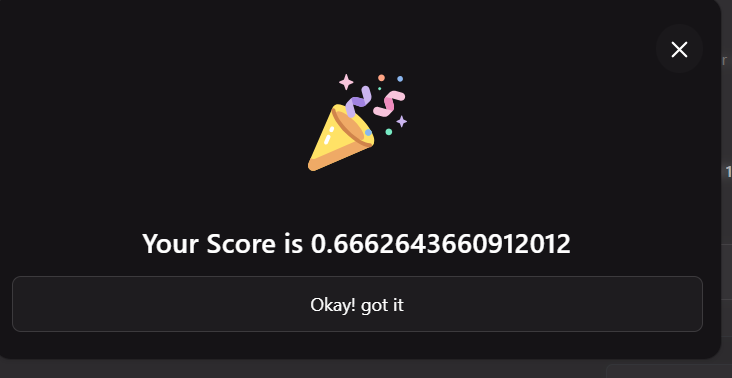

In [124]:
import joblib

In [125]:
joblib.dump(new_model,'jobchg_pipeline_model.pkl')

['jobchg_pipeline_model.pkl']